## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data Cleaning

In [2]:
vehiclesdf_unclean = pd.read_csv("vehicles.csv")

vehiclesdfc = vehiclesdf_unclean[["id","region","region_url","price","year","manufacturer","model","condition","cylinders","state","posting_date"]]

In [3]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,condition,cylinders,state,posting_date
0,7222695916,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,az,NaN
1,7218891961,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,7221797935,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,7222270760,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,7210384030,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [4]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(426880, 11)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   region_url    426880 non-null  object 
 3   price         426880 non-null  int64  
 4   year          425675 non-null  float64
 5   manufacturer  409234 non-null  object 
 6   model         421603 non-null  object 
 7   condition     252776 non-null  object 
 8   cylinders     249202 non-null  object 
 9   state         426880 non-null  object 
 10  posting_date  426812 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 35.8+ MB
None
                 id         price           year
count  4.268800e+05  4.268800e+05  425675.000000
mean   7.311487e+09  7.519903e+04    2011.235191
std    4.473170e+06  1.218228e+07       9.452120
min    7.207408e+09  0.000000e+00    1

In [5]:
# Due to condition and cylinders being at 40% with nAN values then we should drop it 
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"])
vehiclesdfc = vehiclesdfc.dropna()

In [6]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


## Preprocessing

In [7]:
df = vehiclesdfc.copy()
df = df[(df["price"] >= 500) & (df["price"] <= 150_000)]
df["year"] = df["year"].astype(int)

print(f"After outlier removal: {df.shape}")
df["price"].describe()

After outlier removal: (364542, 9)


count    364542.000000
mean      19237.118713
std       14469.706202
min         500.000000
25%        7900.000000
50%       15990.000000
75%       27990.000000
max      150000.000000
Name: price, dtype: float64

## Random Forest

**Feature engineering** 

In [8]:
df_rf = df.copy()

# Limit OHE to top 200 models — freeform Craigslist entries create 22,000+ unique
# model names, which makes training extremely slow. Keeping the top 200 covers the
# vast majority of listings while keeping the feature matrix manageable.
top_models = df_rf["model"].value_counts().nlargest(200).index
df_rf["model_grouped"] = df_rf["model"].where(df_rf["model"].isin(top_models), other="other")
model_ohe = pd.get_dummies(df_rf["model_grouped"], prefix="model", drop_first=True)

# Label encode the remaining low-cardinality categoricals
for col in ["manufacturer", "region", "state"]:
    le = LabelEncoder()
    df_rf[col + "_encoded"] = le.fit_transform(df_rf[col].astype(str))

# Combine all features
base_features = ["year", "manufacturer_encoded", "region_encoded", "state_encoded"]
X_rf = pd.concat([df_rf[base_features], model_ohe], axis=1)
y_rf = df_rf["price"]

print(f"X shape: {X_rf.shape}  (base features + {model_ohe.shape[1]} model dummies)")
print(f"y shape: {y_rf.shape}")

X shape: (364542, 204)  (base features + 200 model dummies)
y shape: (364542,)


**Train/Test Split**

In [9]:
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=0)

**Train model**

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1,random_state=0)
rf_model.fit(X_rf_train, y_rf_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                      random_state=0)

**Evaluate**

In [11]:
y_rf_pred = rf_model.predict(X_rf_test)

mae  = mean_absolute_error(y_rf_test, y_rf_pred)
rmse = np.sqrt(mean_squared_error(y_rf_test, y_rf_pred))
r2   = r2_score(y_rf_test, y_rf_pred)

print(f"MAE :  ${mae:,.0f}")
print(f"RMSE:  ${rmse:,.0f}")
print(f"R²  :  {r2:.3f}")

MAE :  $5,769
RMSE:  $8,747
R²  :  0.628


**Visualization**

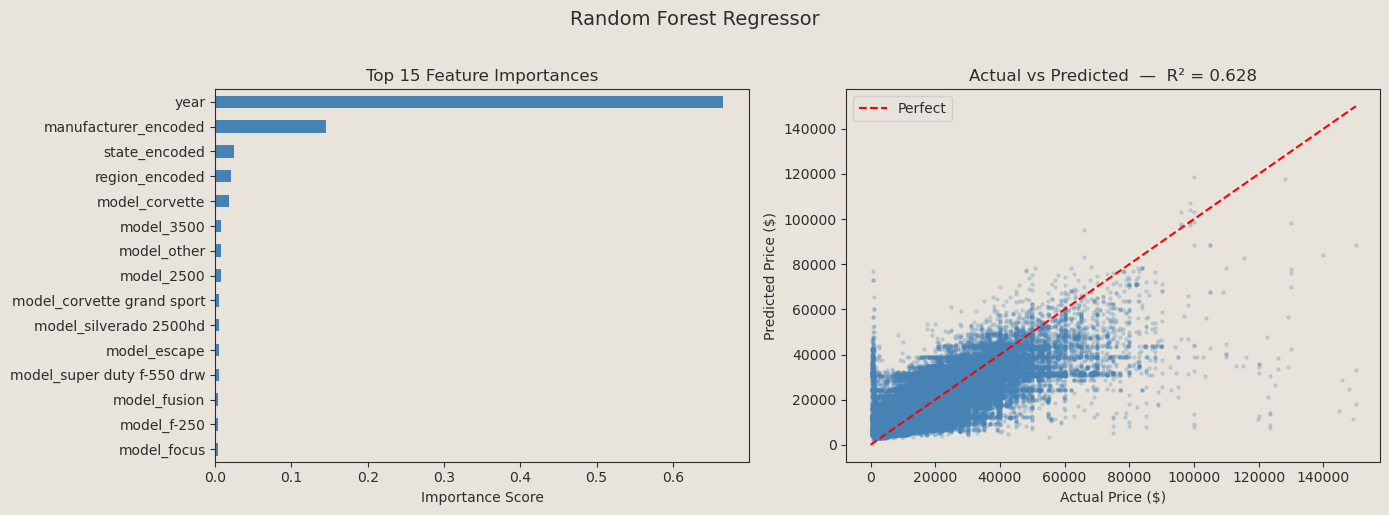

In [14]:
bg_color = "#E8E4DC"
text_color = "#2D2D2D"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.set_facecolor(bg_color)

importances = pd.Series(rf_model.feature_importances_, index=X_rf.columns)
importances.nlargest(15).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_facecolor(bg_color)
axes[0].set_title("Top 15 Feature Importances", color=text_color)
axes[0].set_xlabel("Importance Score", color=text_color)
axes[0].tick_params(colors=text_color)
for spine in axes[0].spines.values():
    spine.set_edgecolor(text_color)

axes[1].set_facecolor(bg_color)
axes[1].scatter(y_rf_test, y_rf_pred, alpha=0.2, s=5, color="steelblue")
axes[1].plot([0, 150_000], [0, 150_000], "r--", linewidth=1.5, label="Perfect")
axes[1].set_xlabel("Actual Price ($)", color=text_color)
axes[1].set_ylabel("Predicted Price ($)", color=text_color)
axes[1].set_title(f"Actual vs Predicted  —  R² = {r2:.3f}", color=text_color)
axes[1].tick_params(colors=text_color)
axes[1].legend(facecolor=bg_color, labelcolor=text_color)
for spine in axes[1].spines.values():
    spine.set_edgecolor(text_color)

plt.suptitle("Random Forest Regressor", fontsize=14, y=1.02, color=text_color)
plt.tight_layout()
plt.show()

## Multiple Linear

**Train/Test Split**

In [ ]:
X_mlr_train, X_mlr_test = X_rf_train, X_rf_test
y_mlr_train, y_mlr_test = y_rf_train, y_rf_test

**Train model**

In [ ]:
mlr_model = LinearRegression(n_jobs=-1)
mlr_model.fit(X_mlr_train, y_mlr_train)

**Evaluation**

In [ ]:
y_mlr_pred = mlr_model.predict(X_mlr_test)

mlr_mae  = mean_absolute_error(y_mlr_test, y_mlr_pred)
mlr_rmse = np.sqrt(mean_squared_error(y_mlr_test, y_mlr_pred))
mlr_r2   = r2_score(y_mlr_test, y_mlr_pred)

print(f"MAE :  ${mlr_mae:,.0f}")
print(f"RMSE:  ${mlr_rmse:,.0f}")
print(f"R²  :  {mlr_r2:.3f}")

**Visualization**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Actual vs Predicted
axes[0].scatter(y_mlr_test, y_mlr_pred, alpha=0.2, s=5, color="darkorange")
axes[0].plot([0, 150_000], [0, 150_000], "r--", linewidth=1.5, label="Perfect")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Actual vs Predicted  —  R² = {mlr_r2:.3f}")
axes[0].legend()

#Top 15 largest absolute coefficients (base features only for clarity)
coef_series = pd.Series(mlr_model.coef_, index=X_rf.columns)
coef_series[base_features].plot(
    kind="barh", ax=axes[1],
    color=["steelblue" if v >= 0 else "tomato" for v in coef_series[base_features]]
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Coefficients — Base Features")
axes[1].set_xlabel("Effect on Price ($)")

plt.suptitle("Multiple Linear Regression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Multiple Linear Regression"],
    "MAE ($)": [f"{rf_mae:,.0f}", f"{mlr_mae:,.0f}"],
    "RMSE ($)": [f"{rf_rmse:,.0f}", f"{mlr_rmse:,.0f}"],
    "R²": [f"{r2:.3f}", f"{mlr_r2:.3f}"]
})
print(comparison.to_string(index=False))